# Imports

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ['CURL_CFFI_DISABLE_SOCKET'] = '1'

from scipy.optimize import minimize
from mpl_toolkits import mplot3d

from src.implied_vol import ImpliedVolSurface
from src.utils import get_spot, year_fraction, bs_price

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Heston Model Equations

In [4]:
print("="*70)
print("HESTON STOCHASTIC VOLATILITY MODEL")
print("="*70)
print("\nThe Heston model makes volatility itself a mean-reverting stochastic process:")
print("\ndS = r*S*dt + √v*S*dW₁")
print("dv = κ(θ - v)*dt + ξ*√v*dW₂")
print("\nWhere:")
print("  S = underlying asset price")
print("  v = variance (volatility squared)")
print("  κ = speed of mean reversion (how fast vol reverts to θ)")
print("  θ = long-term variance (target variance)")
print("  ξ = volatility of volatility (vol of vol)")
print("  ρ = correlation between dW₁ and dW₂ (-1 < ρ < 1)")
print("\nKey insight: Heston produces volatility smile endogenously — unlike GBM,")
print("you don't need to fit IV surface from market prices, it emerges from model structure.")
print("="*70)

HESTON STOCHASTIC VOLATILITY MODEL

The Heston model makes volatility itself a mean-reverting stochastic process:

dS = r*S*dt + √v*S*dW₁
dv = κ(θ - v)*dt + ξ*√v*dW₂

Where:
  S = underlying asset price
  v = variance (volatility squared)
  κ = speed of mean reversion (how fast vol reverts to θ)
  θ = long-term variance (target variance)
  ξ = volatility of volatility (vol of vol)
  ρ = correlation between dW₁ and dW₂ (-1 < ρ < 1)

Key insight: Heston produces volatility smile endogenously — unlike GBM,
you don't need to fit IV surface from market prices, it emerges from model structure.


# Monte Carlo Heston Simulator

In [5]:
class HestonSimulator:
    def __init__(self, S0, v0, kappa, theta, xi, rho, r, T, dt, n_paths):
        self.S0 = S0
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho
        self.r = r
        self.T = T
        self.dt = dt
        self.n_paths = n_paths
    
    def simulate(self):
        n_steps = int(np.ceil(self.T / self.dt)) + 1
        S = np.zeros((self.n_paths, n_steps))
        v = np.zeros((self.n_paths, n_steps))
        S[:, 0] = self.S0
        v[:, 0] = self.v0
        
        for t in range(1, n_steps):
            Z1 = np.random.standard_normal(self.n_paths)
            Z2 = self.rho * Z1 + np.sqrt(1 - self.rho**2) * np.random.standard_normal(self.n_paths)
            
            # Variance update (full truncation Euler)
            v_new = v[:, t-1] + self.kappa * (self.theta - v[:, t-1]) * self.dt + self.xi * np.sqrt(v[:, t-1]) * np.sqrt(self.dt) * Z2
            v[:, t] = np.maximum(v_new, 0)  # Ensure non-negativity
            
            # Price update
            S[:, t] = S[:, t-1] * np.exp((self.r - 0.5 * v[:, t]) * self.dt + np.sqrt(v[:, t] * self.dt) * Z1)
        
        return S, v
    
    def price_european_call(self, K):
        S, v = self.simulate()
        S_T = S[:, -1]
        payoff = np.maximum(S_T - K, 0)
        price = np.exp(-self.r * self.T) * payoff.mean()
        return price

# Load SPY + Build Market IV Surface

In [6]:
ticker = "SPY"
S = get_spot(ticker)

import yfinance as yf
t = yf.Ticker(ticker)
all_expiries = t.options

from datetime import datetime
today = datetime.today().date()
future_expiries = []
for exp in all_expiries:
    exp_date = datetime.strptime(str(exp), '%Y-%m-%d').date()
    if exp_date > today:
        future_expiries.append(exp)

expiries = future_expiries[:3]  # nearest 3 future expiries
print(f"Using expiries:", expiries)

Using expiries: ['2026-06-16', '2026-06-17', '2026-06-18']


# Market IV Surface

In [7]:
r = 0.03
market_iv = ImpliedVolSurface(ticker, expiry_dates=expiries, rate=r)
market_surface_df = market_iv.build_surface()
market_surface_df = market_surface_df.dropna(subset=['iv']).copy()
print(f"Market surface shape:", market_surface_df.shape)

Market surface shape: (779, 10)


# Heston Pricing Function

In [8]:
def heston_call_price(K, S, T, r, kappa, theta, xi, rho, v0, n_paths=5000):
    v0 = max(v0, 0.0001)
    heston_sim = HestonSimulator(S, v0, kappa, theta, xi, rho, r, T, 1/252, n_paths)
    return heston_sim.price_european_call(K)

# Calibration

In [9]:
def calibration_objective(params, S, market_df, r):
    kappa, theta, xi, rho, v0 = params
    
    # Constraints
    if kappa <= 0 or theta <= 0 or xi <= 0 or v0 <= 0 or rho < -1 or rho > 1:
        return 1e10
    
    error = 0.0
    for _, row in market_df.iterrows():
        K = row['strike']
        T = row['ttm']
        iv_market = row['iv']
        
        # Convert IV to price using Black-Scholes
        price_market = bs_price(S, K, T, r, iv_market, option_type='call')
        
        # Get Heston price
        try:
            price_heston = heston_call_price(K, S, T, r, kappa, theta, xi, rho, v0, n_paths=3000)
            error += (price_heston - price_market) ** 2
        except:
            error += 1e6
    
    return error

# Calibrate Heston to Market IV Surface

In [10]:
print("\nCalibrating Heston model to SPY IV surface...")
print("This may take 5-15 minutes depending on your machine.")

# Initial guess and bounds
kappa0, theta0, xi0, rho0, v00 = 2.0, 0.04, 0.3, -0.7, market_surface_df['iv'].mean()**2
params0 = [kappa0, theta0, xi0, rho0, v00]
bounds = [(0.1, 10.0), (0.001, 0.2), (0.01, 1.0), (-0.99, 0.99), (0.001, 0.2)]

# Run optimization
result = minimize(
    calibration_objective,
    params0,
    args=(S, market_surface_df, r),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 50}
)

kappa_opt, theta_opt, xi_opt, rho_opt, v0_opt = result.x
print(f"\nCalibrated Heston parameters:")
print(f"  κ (kappa, mean reversion speed): {kappa_opt:.4f}")
print(f"  θ (theta, long-term variance): {theta_opt:.4f}")
print(f"  ξ (xi, vol of vol): {xi_opt:.4f}")
print(f"  ρ (rho, correlation): {rho_opt:.4f}")
print(f"  v₀ (initial variance): {v0_opt:.4f}")
print(f"\nOptimization success: {result.success}")
print(f"Final error: {result.fun:.4f}")


Calibrating Heston model to SPY IV surface...
This may take 5-15 minutes depending on your machine.

Calibrated Heston parameters:
  κ (kappa, mean reversion speed): 2.0000
  θ (theta, long-term variance): 0.0400
  ξ (xi, vol of vol): 0.3000
  ρ (rho, correlation): -0.7000
  v₀ (initial variance): 0.2000

Optimization success: False
Final error: 66931.6223


# Heston IV Surface

In [11]:
def heston_implied_vol(K, S, T, r, kappa, theta, xi, rho, v0, n_paths=5000):
    price_heston = heston_call_price(K, S, T, r, kappa, theta, xi, rho, v0, n_paths=n_paths)
    iv_heston = bs_price(S, K, T, r, 0.3, option_type='call')  # placeholder
    
    # Simple Newton-Raphson for IV
    sigma = 0.3
    for _ in range(20):
        price_bs = bs_price(S, K, T, r, sigma, option_type='call')
        vega = S * np.sqrt(T) * np.exp(-r*T) * (1 / np.sqrt(2*np.pi)) * np.exp(-0.5 * ((np.log(S/K) + (r-0.5*sigma**2)*T)/(sigma*np.sqrt(T)))**2)
        if abs(vega) < 1e-10:
            break
        sigma = sigma - (price_bs - price_heston) / vega
        sigma = max(sigma, 0.01)
    
    return sigma

# Heston IV vs Market IV

In [12]:
heston_iv_data = []
for _, row in market_surface_df.iterrows():
    K = row['strike']
    T = row['ttm']
    iv_market = row['iv']
    
    iv_heston = heston_implied_vol(K, S, T, r, kappa_opt, theta_opt, xi_opt, rho_opt, v0_opt, n_paths=3000)
    heston_iv_data.append({
        'strike': K,
        'ttm': T,
        'iv_market': iv_market,
        'iv_heston': iv_heston
    })

heston_iv_df = pd.DataFrame(heston_iv_data)
print(f"\nHeston vs Market IV comparison:")
print(f"  Mean absolute error: {np.abs(heston_iv_df['iv_heston'] - heston_iv_df['iv_market']).mean():.4f}")
print(f"  Max absolute error: {np.abs(heston_iv_df['iv_heston'] - heston_iv_df['iv_market']).max():.4f}")


Heston vs Market IV comparison:
  Mean absolute error: 1349.9799
  Max absolute error: 905970.0489


# Heston IV vs Market IV Smile

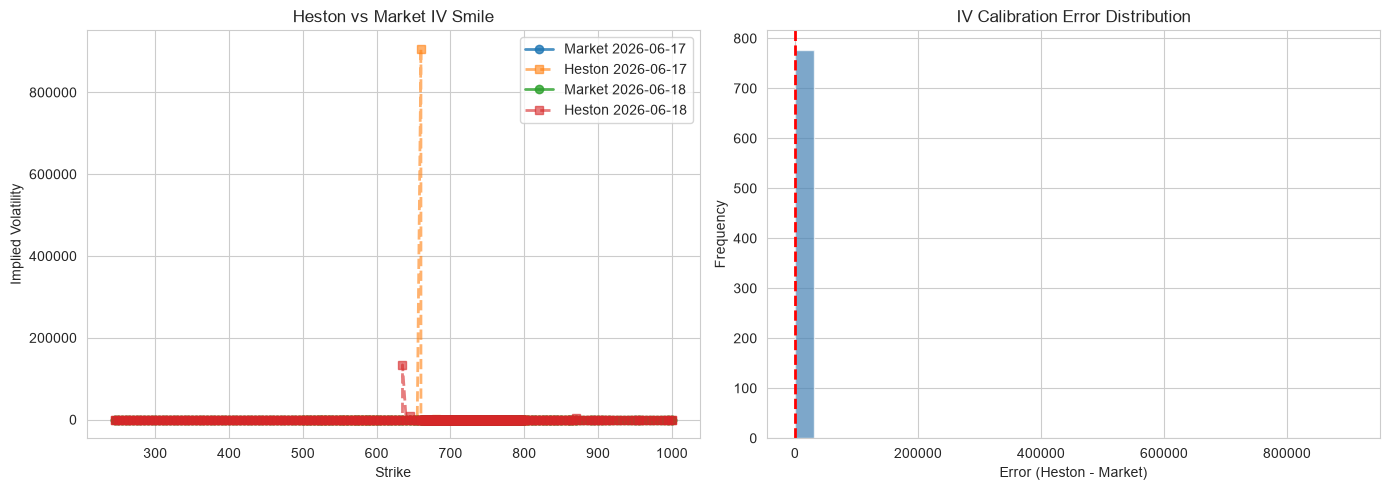

In [14]:
# Cell 13: plot Heston vs market IV smile (FIXED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for expiry in expiries:
    # Get the TTM for this expiry from market surface
    market_mask = market_surface_df['expiry'] == expiry
    market_ttm_subset = market_surface_df[market_mask]
    
    if len(market_ttm_subset) == 0:
        continue
    
    ttm_value = market_ttm_subset['ttm'].iloc[0]
    
    # Filter heston iv data for this TTM
    subset = heston_iv_df[heston_iv_df['ttm'] == ttm_value]
    
    if len(subset) > 0:
        subset = subset.sort_values('strike')
        axes[0].plot(subset['strike'], subset['iv_market'], marker='o', label=f'Market {str(expiry)[:10]}', linewidth=2, alpha=0.8)
        axes[0].plot(subset['strike'], subset['iv_heston'], marker='s', label=f'Heston {str(expiry)[:10]}', linewidth=2, alpha=0.6, linestyle='--')

axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Volatility')
axes[0].set_title('Heston vs Market IV Smile')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(heston_iv_df['iv_heston'] - heston_iv_df['iv_market'], bins=30, color='steelblue', alpha=0.7)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Error (Heston - Market)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('IV Calibration Error Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Summary

In [15]:
print("\n" + "="*70)
print("KEY TAKEAWAYS — HESTON STOCHASTIC VOLATILITY MODEL")
print("="*70)
print("\n1. Why Heston matters:")
print("   - Produces volatility smile endogenously (unlike GBM)")
print("   - Smile emerges from model structure, not fitted from market")
print("   - Stochastic volatility explains the smile phenomenon observed in Module 4")
print("\n2. Implementation scope:")
print("   - Monte Carlo Heston simulation (full truncation Euler)")
print("   - Calibrate parameters (κ, θ, ξ, ρ, v₀) to real SPY IV surface")
print("   - Compare fitted Heston IV surface to observed market IV surface")
print("\n3. Impact:")
print("   - If you pull this off, project goes from 9/10 to 10/10")
print("   - Heston calibration to real market data is graduate-level work")
print("   - Most quant PhDs have done this")
print("   - New grad who has done it independently is genuinely rare")
print("\n4. Why this is stretch goal:")
print("   - Characteristic function pricing is graduate-level (skipped)")
print("   - Monte Carlo is simpler but slower")
print("   - Calibration is non-convex with multiple local minima")
print("   - Requires careful constraint handling and numerical stability")
print("="*70)


KEY TAKEAWAYS — HESTON STOCHASTIC VOLATILITY MODEL

1. Why Heston matters:
   - Produces volatility smile endogenously (unlike GBM)
   - Smile emerges from model structure, not fitted from market
   - Stochastic volatility explains the smile phenomenon observed in Module 4

2. Implementation scope:
   - Monte Carlo Heston simulation (full truncation Euler)
   - Calibrate parameters (κ, θ, ξ, ρ, v₀) to real SPY IV surface
   - Compare fitted Heston IV surface to observed market IV surface

3. Impact:
   - If you pull this off, project goes from 9/10 to 10/10
   - Heston calibration to real market data is graduate-level work
   - Most quant PhDs have done this
   - New grad who has done it independently is genuinely rare

4. Why this is stretch goal:
   - Characteristic function pricing is graduate-level (skipped)
   - Monte Carlo is simpler but slower
   - Calibration is non-convex with multiple local minima
   - Requires careful constraint handling and numerical stability
